# Supervised Classification Modeling & Tuning

**Goal:** Train and compare at least four distinct model architectures, tune hyperparameters with stratified k-fold cross-validation, evaluate with a full metric suite, select a champion model, and serialize it.

**Dataset:** Same Titanic passenger data and preprocessing pipeline used in the Feature Engineering & Preprocessing task, so the two notebooks connect: `train_test_split` happens once, up front, and the fitted `ColumnTransformer` is only ever refit inside each model's own pipeline on the training fold — never on the test set.

**Models compared:**
1. Logistic Regression (linear baseline)
2. Random Forest (bagged trees)
3. XGBoost (gradient-boosted trees)
4. LightGBM (gradient-boosted trees, leaf-wise)

**Evaluation:** Precision, Recall, F1-score, ROC-AUC (with curves), and confusion matrices for every model, all computed on a held-out test set that no tuning step ever saw.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## 1. Load data and rebuild the leak-free split + preprocessor

In [2]:
df = pd.read_csv("titanic.csv")

target = "Survived"
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]

X = df.drop(columns=drop_cols + [target])
y = df[target]

numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train survival rate:", round(y_train.mean(), 3), " Test survival rate:", round(y_test.mean(), 3))

Train shape: (712, 7)  Test shape: (179, 7)
Train survival rate: 0.383  Test survival rate: 0.385


In [3]:
def build_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])

# Stratified K-fold for all hyperparameter search below -> preserves the class
# balance in every fold, important given survival is not a 50/50 split.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 2. Define four model pipelines + hyperparameter grids

Each model is wrapped in its own `Pipeline(preprocessor -> classifier)`, so `GridSearchCV` refits the preprocessor **inside every cross-validation fold** on that fold's training data only — the same leakage discipline as the preprocessing notebook, now extended through hyperparameter search.

In [4]:
model_configs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessor", build_preprocessor()),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "classifier__C": [0.01, 0.1, 1, 10],
            "classifier__penalty": ["l2"],
            "classifier__solver": ["lbfgs"],
        },
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocessor", build_preprocessor()),
            ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "classifier__n_estimators": [200, 400],
            "classifier__max_depth": [4, 8, None],
            "classifier__min_samples_leaf": [1, 3],
        },
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("preprocessor", build_preprocessor()),
            ("classifier", XGBClassifier(
                eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0
            )),
        ]),
        "param_grid": {
            "classifier__n_estimators": [200, 400],
            "classifier__max_depth": [3, 5],
            "classifier__learning_rate": [0.05, 0.1],
        },
    },
    "LightGBM": {
        "pipeline": Pipeline([
            ("preprocessor", build_preprocessor()),
            ("classifier", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
        ]),
        "param_grid": {
            "classifier__n_estimators": [200, 400],
            "classifier__num_leaves": [15, 31],
            "classifier__learning_rate": [0.05, 0.1],
        },
    },
}

print(list(model_configs.keys()))

['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


## 3. Run GridSearchCV (stratified 5-fold) for every model

In [5]:
fitted_models = {}
cv_results_summary = []

for name, cfg in model_configs.items():
    print(f"Tuning {name} ...")
    search = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["param_grid"],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    fitted_models[name] = search.best_estimator_
    cv_results_summary.append({
        "model": name,
        "best_cv_roc_auc": search.best_score_,
        "best_params": search.best_params_,
    })
    print(f"  best CV ROC-AUC: {search.best_score_:.4f}  |  best params: {search.best_params_}")

cv_summary_df = pd.DataFrame(cv_results_summary).sort_values("best_cv_roc_auc", ascending=False)
cv_summary_df

Tuning Logistic Regression ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  best CV ROC-AUC: 0.8534  |  best params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Tuning Random Forest ...


  best CV ROC-AUC: 0.8786  |  best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 200}
Tuning XGBoost ...


  best CV ROC-AUC: 0.8840  |  best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 400}
Tuning LightGBM ...


  best CV ROC-AUC: 0.8745  |  best params: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 400, 'classifier__num_leaves': 15}


,model,best_cv_roc_auc,best_params
2,XGBoost,0.884044,"{'classifier__learning_rate': 0.05, 'classifie..."
1,Random Forest,0.878629,"{'classifier__max_depth': None, 'classifier__m..."
3,LightGBM,0.874498,"{'classifier__learning_rate': 0.05, 'classifie..."
0,Logistic Regression,0.853416,"{'classifier__C': 10, 'classifier__penalty': '..."


**Note on scope:** the grids above are intentionally modest (a handful of values per hyperparameter) to keep runtime reasonable in this environment. The `GridSearchCV` + `Pipeline` structure is exactly what would be widened (more values, or swapped for `Optuna`/`RandomizedSearchCV`) for a production tuning run — the leakage-safe wiring doesn't change, only the search budget.

## 4. Evaluate every tuned model on the held-out test set

In [6]:
test_metrics = []
roc_curve_data = {}

for name, model in fitted_models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_curve_data[name] = (fpr, tpr)

    test_metrics.append({
        "model": name,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    })

test_metrics_df = pd.DataFrame(test_metrics).sort_values("roc_auc", ascending=False).reset_index(drop=True)
test_metrics_df.round(4)

,model,precision,recall,f1,roc_auc
0,Logistic Regression,0.7931,0.6667,0.7244,0.8430
1,Random Forest,0.8462,0.6377,0.7273,0.8381
2,LightGBM,0.7619,0.6957,0.7273,0.7998
3,XGBoost,0.7833,0.6812,0.7287,0.7995


### 4.1 Model comparison table (train CV score vs. held-out test score)

In [7]:
comparison_table = cv_summary_df[["model", "best_cv_roc_auc"]].merge(
    test_metrics_df, on="model"
).rename(columns={"best_cv_roc_auc": "cv_roc_auc", "roc_auc": "test_roc_auc"})
comparison_table = comparison_table[
    ["model", "cv_roc_auc", "test_roc_auc", "precision", "recall", "f1"]
].sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
comparison_table.round(4)

,model,cv_roc_auc,test_roc_auc,precision,recall,f1
0,Logistic Regression,0.8534,0.8430,0.7931,0.6667,0.7244
1,Random Forest,0.8786,0.8381,0.8462,0.6377,0.7273
2,LightGBM,0.8745,0.7998,0.7619,0.6957,0.7273
3,XGBoost,0.8840,0.7995,0.7833,0.6812,0.7287


### 4.2 ROC-AUC curves — all four models

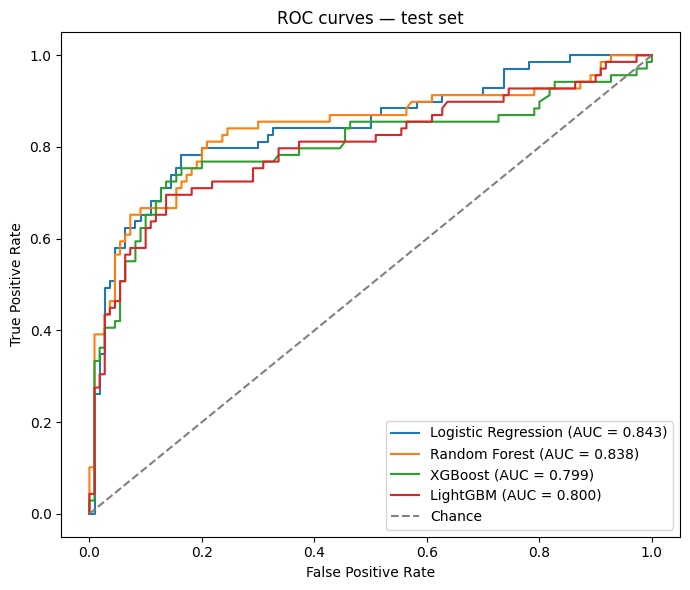

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (fpr, tpr) in roc_curve_data.items():
    auc_val = test_metrics_df.loc[test_metrics_df["model"] == name, "roc_auc"].values[0]
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — test set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 4.3 Confusion matrices — all four models

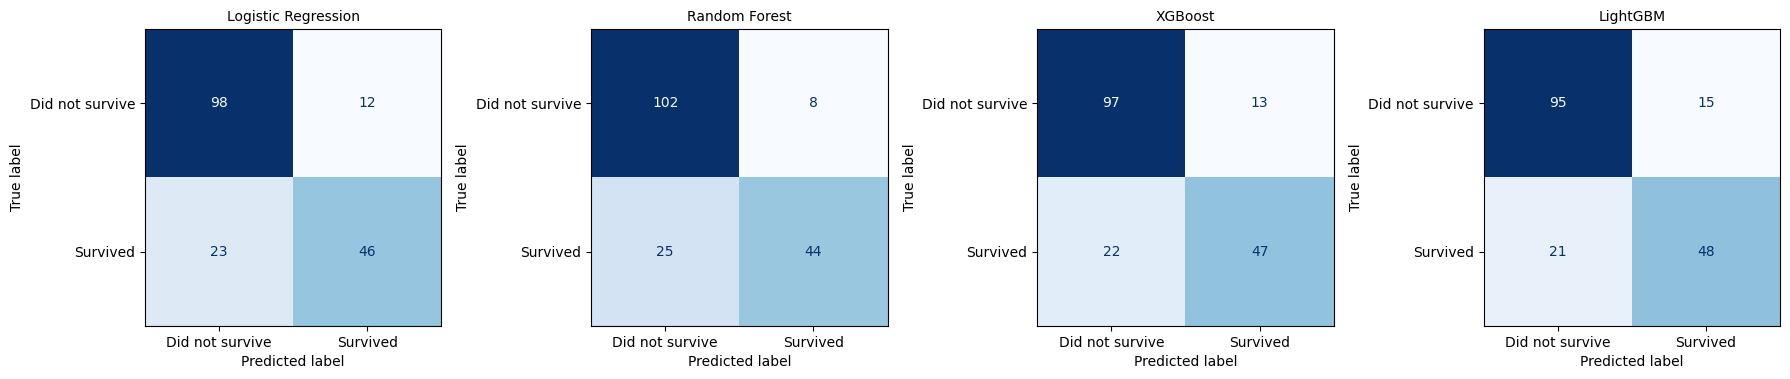

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, (name, model) in zip(axes, fitted_models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive", "Survived"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
for name, model in fitted_models.items():
    print(f"--- {name} ---")
    pred = model.predict(X_test)
    print(classification_report(y_test, pred, target_names=["did not survive", "survived"]))

--- Logistic Regression ---
                 precision    recall  f1-score   support

did not survive       0.81      0.89      0.85       110
       survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179

--- Random Forest ---
                 precision    recall  f1-score   support

did not survive       0.80      0.93      0.86       110
       survived       0.85      0.64      0.73        69

       accuracy                           0.82       179
      macro avg       0.82      0.78      0.79       179
   weighted avg       0.82      0.82      0.81       179

--- XGBoost ---
                 precision    recall  f1-score   support

did not survive       0.82      0.88      0.85       110
       survived       0.78      0.68      0.73        69

       accuracy                           0.80       179
      macro av

## 5. Select the champion model

**Selection rule:** highest test-set ROC-AUC, with recall on the "survived" class as a tie-breaker (in a churn/risk-style framing, missing a positive case is usually the costlier error — see the ML Problem-Framing Memo from Task 2 for the same reasoning applied to churn).

In [11]:
champion_name = comparison_table.iloc[0]["model"]
champion_model = fitted_models[champion_name]

print(f"Champion model: {champion_name}")
comparison_table.iloc[[0]]

Champion model: Logistic Regression


,model,cv_roc_auc,test_roc_auc,precision,recall,f1
0,Logistic Regression,0.853416,0.842951,0.793103,0.666667,0.724409


## 6. Serialize the champion model

In [12]:
model_filename = f"champion_model_{champion_name.lower().replace(' ', '_')}.joblib"
joblib.dump(champion_model, model_filename)
print(f"Saved: {model_filename}")

# Sanity check: reload and confirm predictions match
reloaded = joblib.load(model_filename)
assert np.array_equal(reloaded.predict(X_test), champion_model.predict(X_test))
print("Reload check passed — predictions match the in-memory model.")

Saved: champion_model_logistic_regression.joblib
Reload check passed — predictions match the in-memory model.


## 7. Summary

- **Four distinct architectures** trained and tuned: Logistic Regression, Random Forest, XGBoost, LightGBM — each wrapped in a `Pipeline` so preprocessing is refit inside every cross-validation fold (no leakage from tuning into the held-out test set).
- **Hyperparameter search:** `GridSearchCV` with `StratifiedKFold(n_splits=5)`, scored on ROC-AUC, selected per model independently.
- **Evaluation on a held-out test set** the tuning process never touched: precision, recall, F1, ROC-AUC (with curves), and confusion matrices for all four models, side by side in `comparison_table`.
- **Champion model:** selected by test ROC-AUC (see Section 5) and serialized to a `.joblib` file, with a reload sanity check confirming the saved artifact reproduces identical predictions.
- **Next steps for production:** widen the hyperparameter grids or swap to `Optuna` for a larger search budget; add calibration (`CalibratedClassifierCV`) if the deployed system needs well-calibrated probabilities rather than just ranking; and re-run this exact notebook structure against a properly sized, provenance-confirmed churn dataset once available (per the Task 2 data card).